In [1]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from cnn_host import train_cnn
from data_proc.mock_data import gen_signal

In [2]:
N = 1000
DATA_SAMPLES = 1
time = np.linspace(0, 10 * np.pi, N, dtype=np.float32)

In [3]:
data = [gen_signal(N, time) for i in range(DATA_SAMPLES)]

noisy_audio = [i[0] for i in data]
clean_audio = [i[1] for i in data]

weights, bias, loss_hist = train_cnn(noisy_audio, clean_audio, N, lr=1e-5, BATCH_SIZE=1)


Reverse differentiation of function rev_cnn_loss:
def rev_cnn_loss(noisy : In[Array[float]], _dnoisy_D4TUjn : Out[Array[float]], clean : In[Array[float]], _dclean_hp8QDy : Out[Array[float]], weights : In[Array[float]], _dweights_9h4bgL : Out[Array[float]], bias : In[float], _dbias_utqGuB : Out[float], N : In[int], _dN_08Vet2 : Out[int], K : In[int], _dK_JDxs8a : Out[int], _dreturn_whKGMt : In[float]) -> void:
	_t_float_avrEnf : Array[float, 410000]
	_stack_ptr_float_avrEnf : int = (int)(0)
	_t_int_9i8nr4 : Array[int, 400000]
	_stack_ptr_int_9i8nr4 : int = (int)(0)
	_loop_var_0_SHS6eS : int
	_loop_var_1_P9mUpn : int
	_loop_var_1_P9mUpn_stack : Array[int, 10000]
	_loop_var_1_P9mUpn_stack_ptr : int
	loss : float = (float)(0.0)
	_dloss_A0QlA8 : float
	i : int = (K) - ((int)(1))
	sum : float = (float)(0.0)
	_dsum_puQw9m : float
	j : int = (int)(0)
	diff : float = (float)(0.0)
	_ddiff_eqpPIk : float
	_loop_var_0_SHS6eS = (int)(0)
	while (i) < (N) :
		(_t_float_avrEnf)[_stack_ptr_float_avrEn

training...: 100%|██████████| 250/250 [00:00<00:00, 8593.19it/s]

Epoch 0 | Loss: 3110.2422
Epoch 10 | Loss: 665.3796
Epoch 20 | Loss: 486.4367
Epoch 30 | Loss: 359.1925
Epoch 40 | Loss: 268.4656
Epoch 50 | Loss: 203.6219
Epoch 60 | Loss: 157.1796
Epoch 70 | Loss: 123.8541
Epoch 80 | Loss: 99.9013
Epoch 90 | Loss: 82.6590
Epoch 100 | Loss: 70.2308
Epoch 110 | Loss: 61.2613
Epoch 120 | Loss: 54.7808
Epoch 130 | Loss: 50.0934
Epoch 140 | Loss: 46.6993
Epoch 150 | Loss: 44.2390
Epoch 160 | Loss: 42.4537
Epoch 170 | Loss: 41.1566
Epoch 180 | Loss: 40.2129
Epoch 190 | Loss: 39.5253
Epoch 200 | Loss: 39.0234
Epoch 210 | Loss: 38.6563
Epoch 220 | Loss: 38.3872
Epoch 230 | Loss: 38.1893
Epoch 240 | Loss: 38.0432


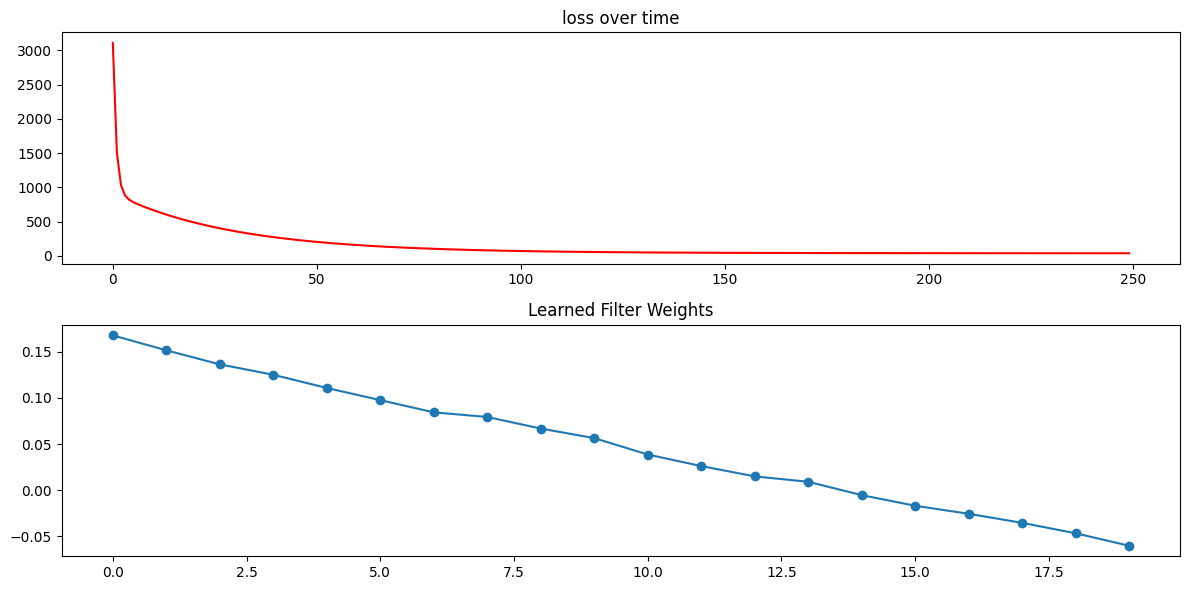

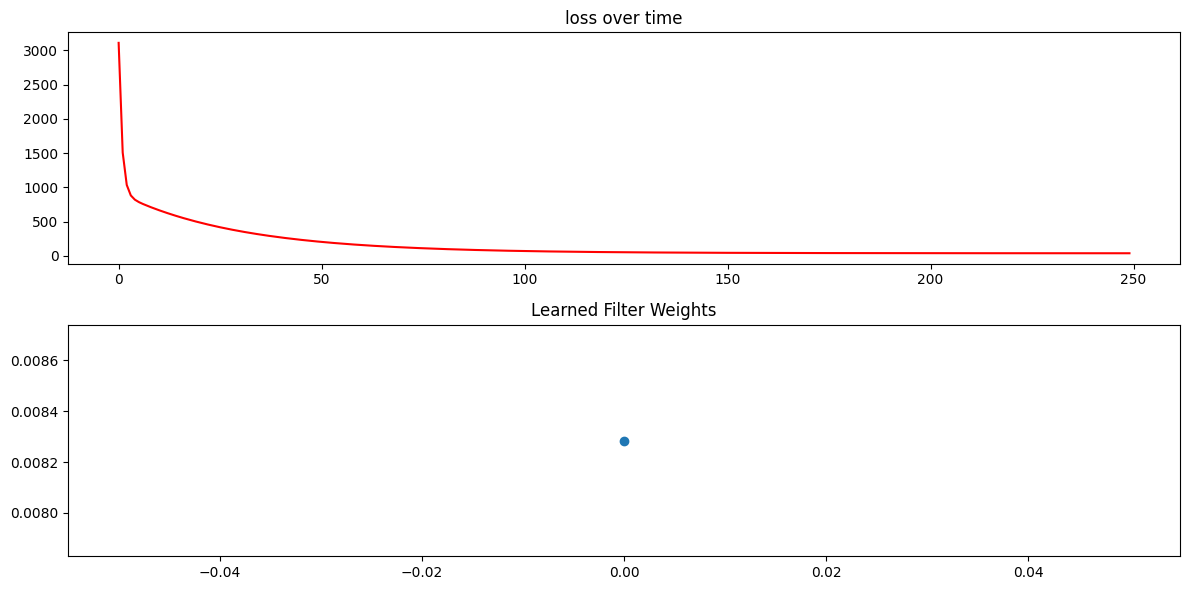

In [4]:
gen_plots(weights, loss_hist)
gen_plots(bias, loss_hist)

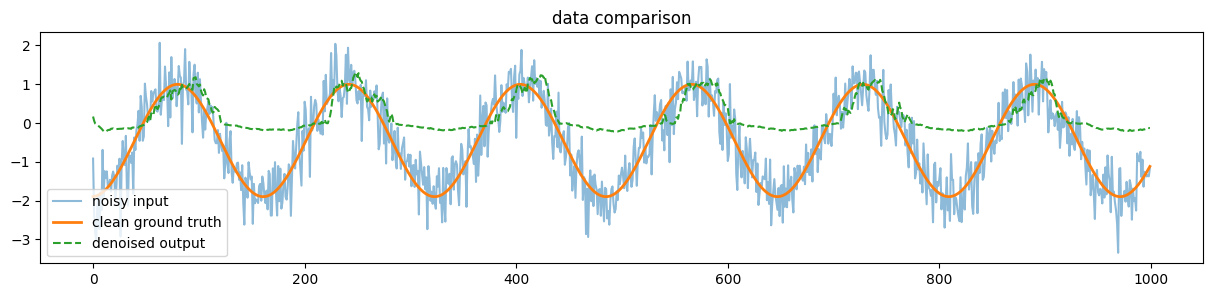

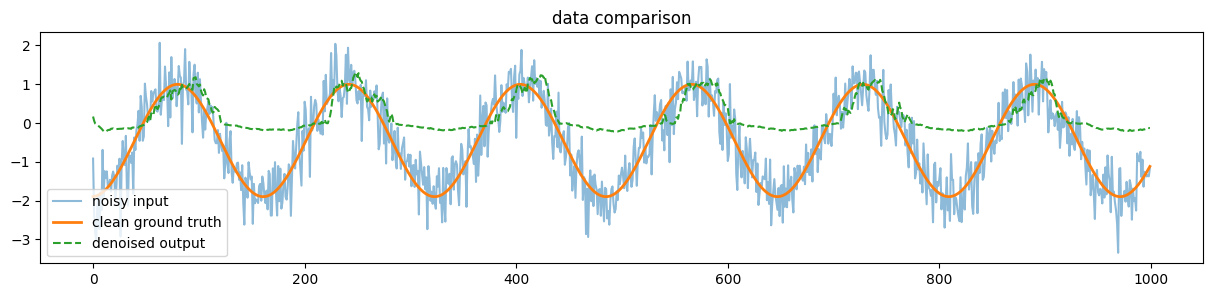

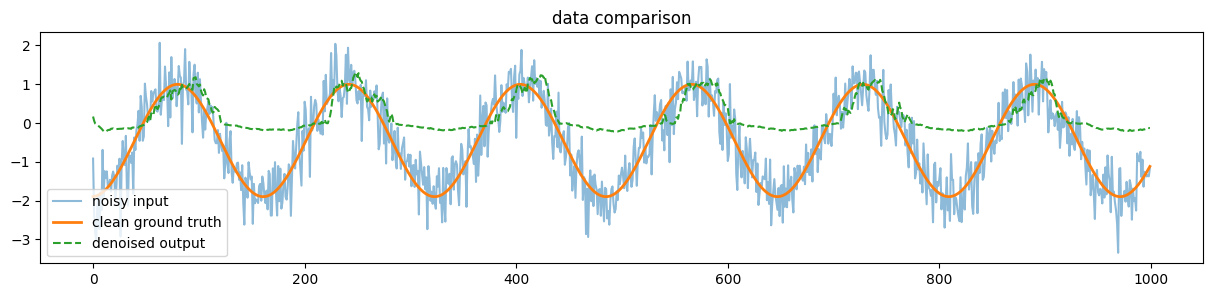

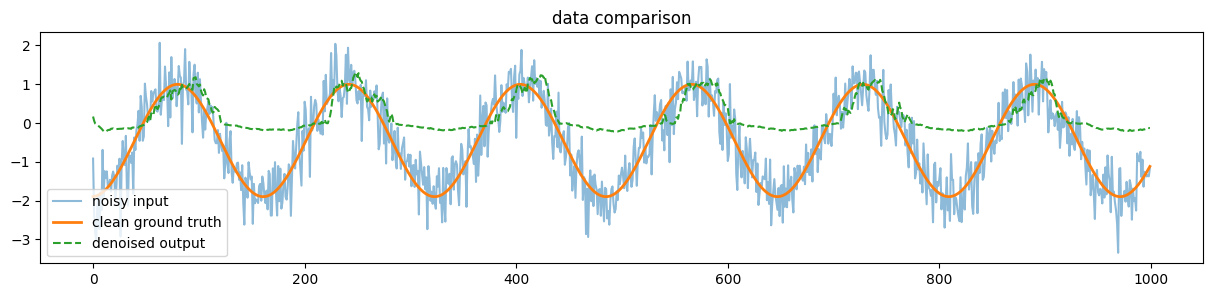

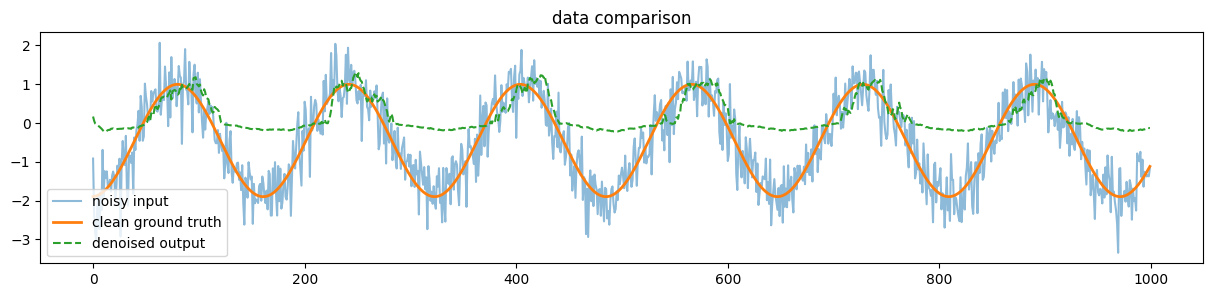

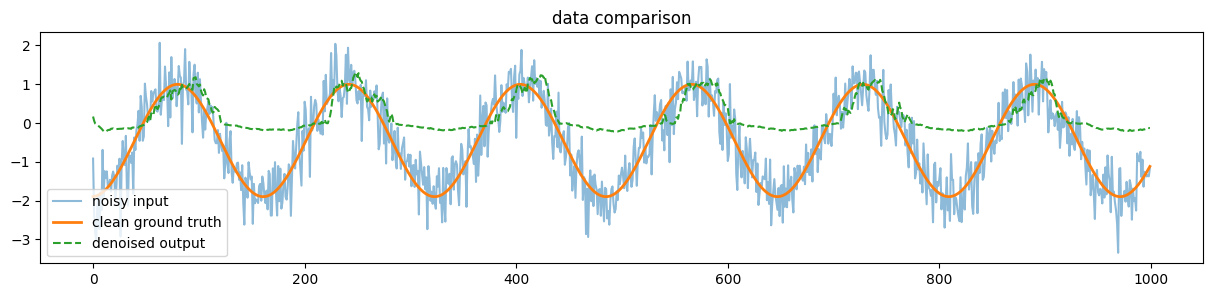

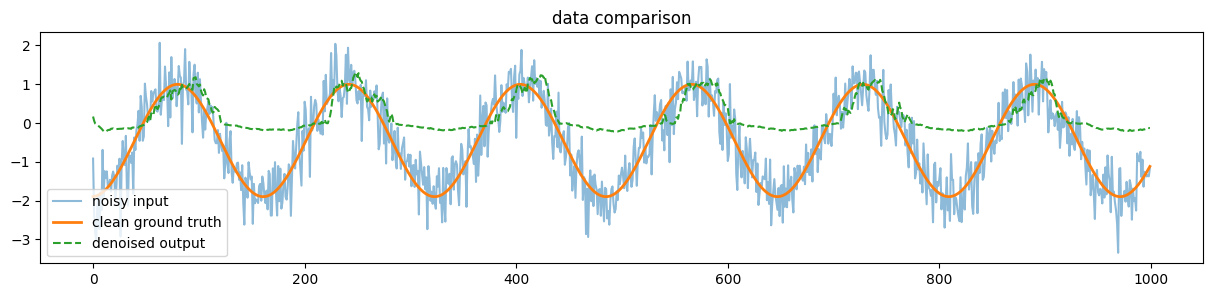

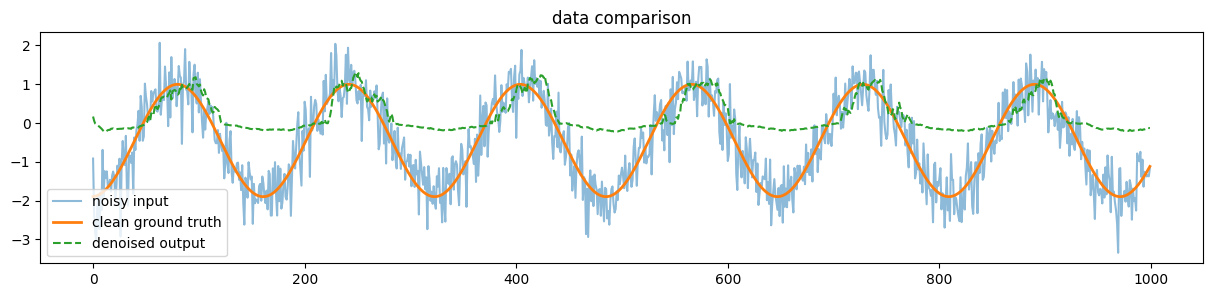

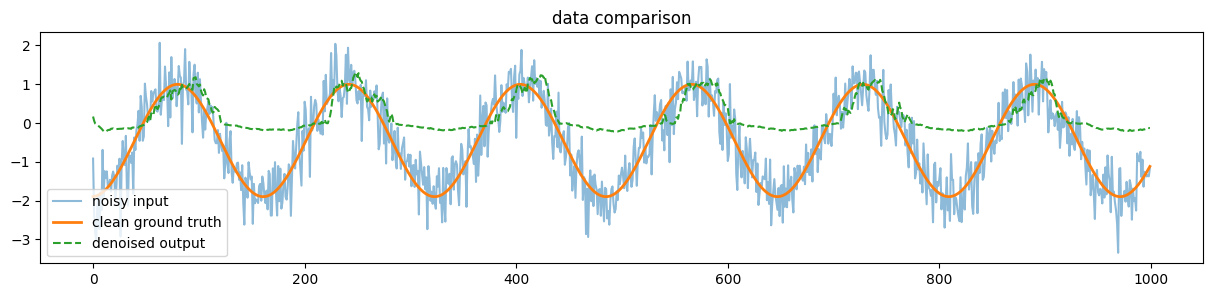

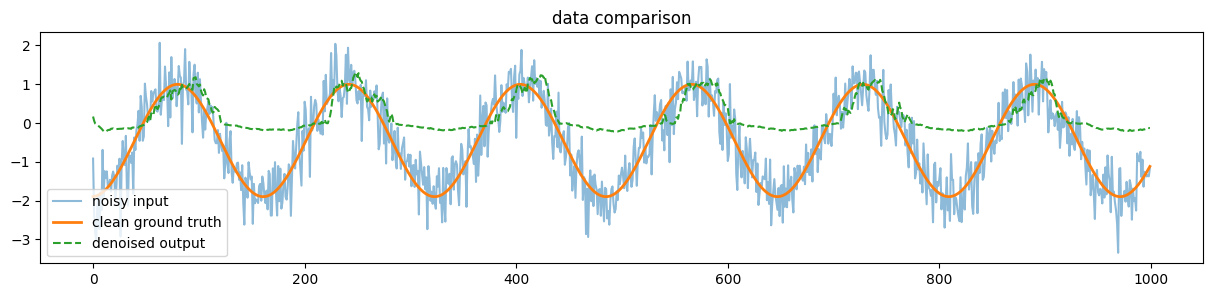

In [5]:
# peak to see on some samples
import matplotlib.pyplot as plt

def peak_sample_perf(noisy_sample, clean_sample, weights, bias):
    plt.figure(figsize=(15, 3))
    # apply a 1D CNN-style linear layer with the learned kernel and bias
    kernel = np.asarray(weights, dtype=np.float32)
    bias_val = float(bias) # Assuming you trained a bias

    pad_left = len(kernel) // 2
    pad_right = len(kernel) - 1 - pad_left
    padded = np.pad(noisy_sample, (pad_left, pad_right), mode="constant")
    windows = np.lib.stride_tricks.sliding_window_view(padded, len(kernel))

    linear_sum = windows @ kernel + bias_val

    denoised_audio = np.where(linear_sum > 0.0, linear_sum, linear_sum * 0.1)

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

for i in range(10):
    idx = np.random.randint(0, len(noisy_audio))

    noisy_sample = noisy_audio[idx]
    clean_sample = clean_audio[idx]

    peak_sample_perf(noisy_sample, clean_sample, weights, bias)